In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, make_scorer
from sklearn.ensemble import GradientBoostingRegressor

In [3]:
RANDOM_STATE = 1031

In [2]:
analysis = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/analysis_data.csv')
scoring = pd.read_csv('/Users/chintanjikkar/Desktop/PACE/Fall 25/Predictive Analytics/Assignments/PAC/Data/scoring_data.csv')

print(analysis.shape, scoring.shape)
analysis.head()

(40000, 23) (10000, 22)


,customer_id,age,gender,marital_status,education_level,region,employment_status,owns_home,has_auto_loan,annual_income,...,card_type,num_transactions,avg_transaction_value,online_shopping_freq,reward_points_balance,travel_frequency,utility_payment_count,num_children,num_credit_cards,monthly_spend
0,75570383,77,female,married,high school,northeast,unemployed,1,0,56000.116893,...,standard,14,46.144967,8.0,6325.578928,3,3.0,1,8,1682.86
1,77915507,52,male,married,high school,south,unemployed,1,1,39432.589311,...,gold,13,88.532219,7.0,5586.814175,1,1.0,2,8,2135.57
2,31958910,48,female,married,bachelors,west,unemployed,1,1,51020.949673,...,standard,9,78.304445,4.0,6250.225115,3,2.0,0,8,1540.61
3,76868487,67,female,married,high school,northeast,unemployed,1,0,76794.566399,...,standard,10,54.932667,7.0,8875.409103,3,3.0,2,8,1250.86
4,69435006,21,female,single,bachelors,west,self-employed,1,1,44386.444631,...,standard,8,18.866712,6.0,5318.021523,4,3.0,0,8,915.36


In [4]:
# =========================================
# 2. Basic data cleaning
# =========================================

# a) Check dtypes & missing values
print("Dtypes:\n", analysis.dtypes)
print("\nMissing values (analysis):\n", analysis.isna().sum())

# b) Drop exact duplicate rows (if any)
before_dups = analysis.shape[0]
analysis = analysis.drop_duplicates()
after_dups = analysis.shape[0]
print(f"\nDropped {before_dups - after_dups} duplicate rows from analysis.")

# c) Ensure key columns are non-negative
non_negative_cols = [
    "age", "num_children", "annual_income", "credit_score",
    "num_credit_cards", "credit_limit", "tenure",
    "num_transactions", "avg_transaction_value",
    "online_shopping_freq", "reward_points_balance",
    "travel_frequency", "utility_payment_count",
    "monthly_spend"
]

for col in non_negative_cols:
    if col in analysis.columns:
        analysis[col] = analysis[col].clip(lower=0)

# Do the same clipping for scoring (except target)
for col in non_negative_cols:
    if col in scoring.columns and col != "monthly_spend":
        scoring[col] = scoring[col].clip(lower=0)

Dtypes:
 customer_id                int64
age                        int64
gender                    object
marital_status            object
education_level           object
region                    object
employment_status         object
owns_home                  int64
has_auto_loan              int64
annual_income            float64
credit_score             float64
credit_limit             float64
tenure                     int64
card_type                 object
num_transactions           int64
avg_transaction_value    float64
online_shopping_freq     float64
reward_points_balance    float64
travel_frequency           int64
utility_payment_count    float64
num_children               int64
num_credit_cards           int64
monthly_spend            float64
dtype: object

Missing values (analysis):
 customer_id                 0
age                         0
gender                      0
marital_status              0
education_level          1199
region                      0
employmen

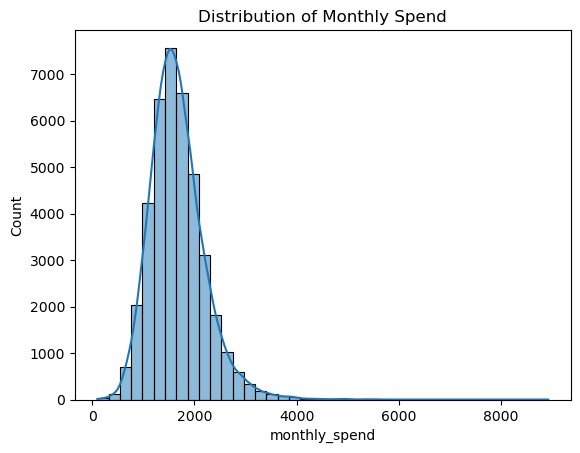

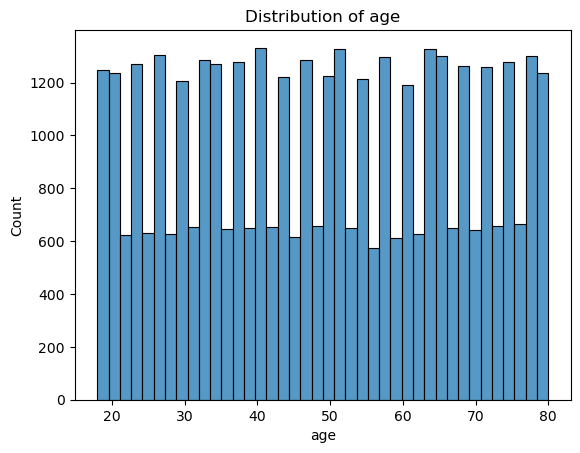

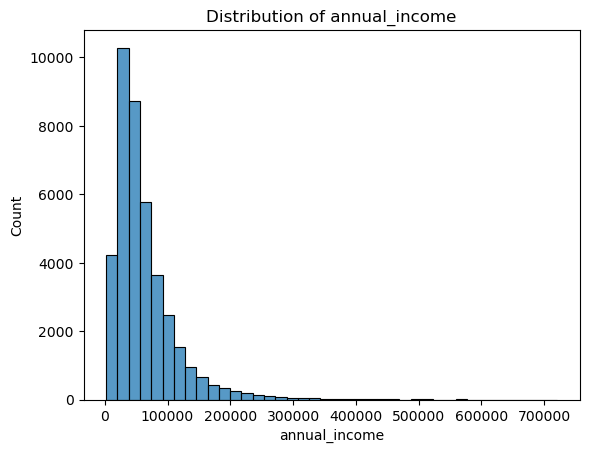

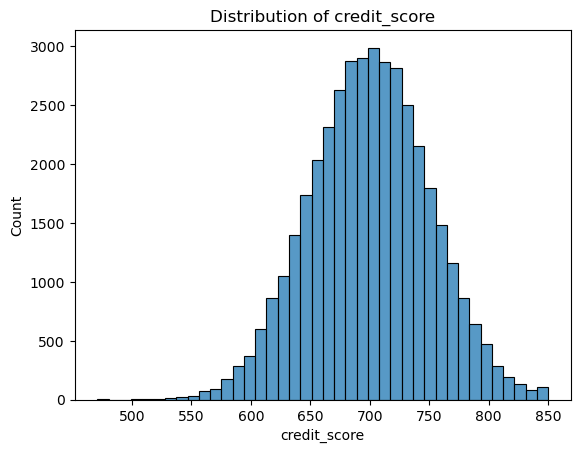

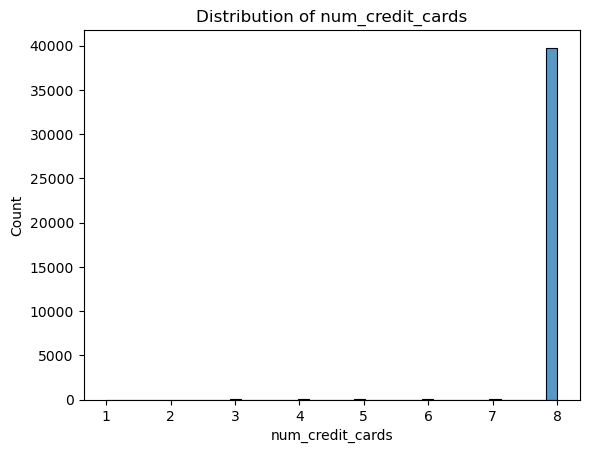

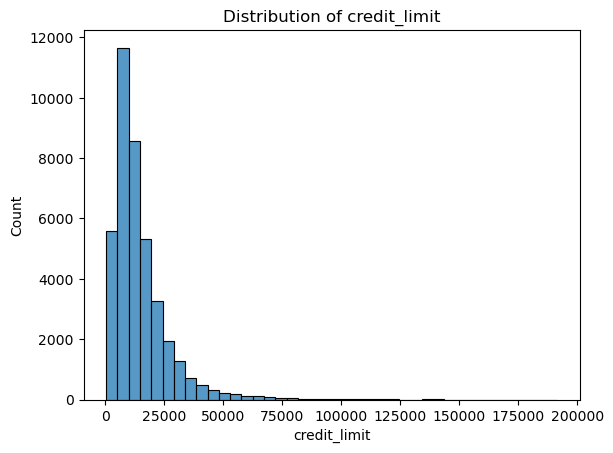

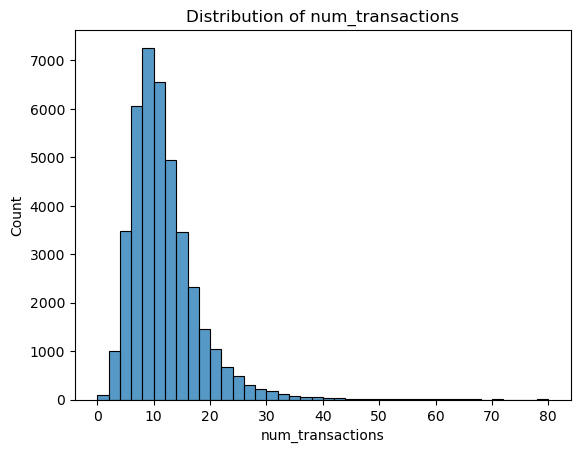

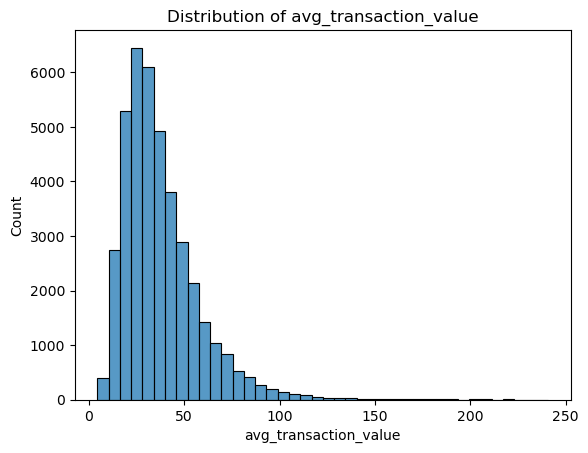

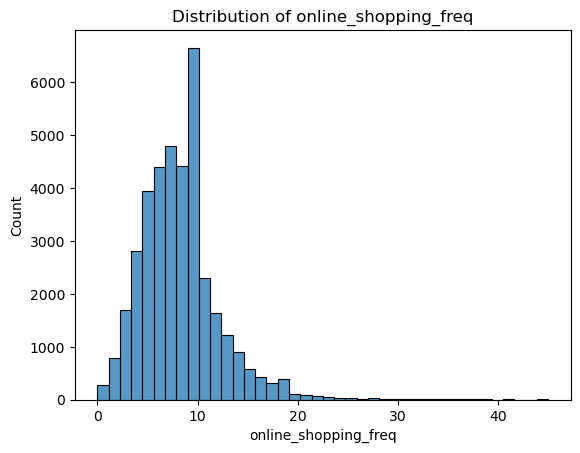

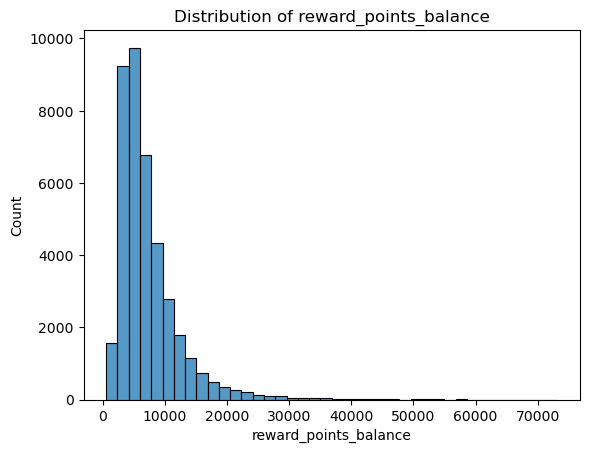

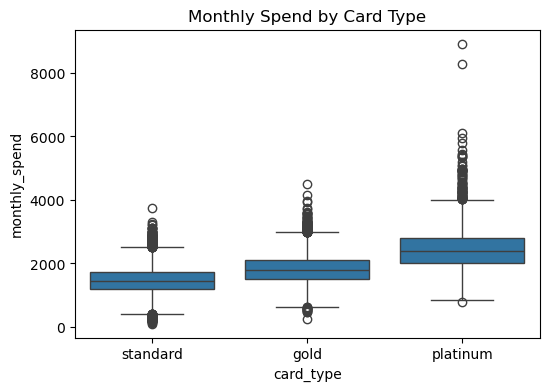

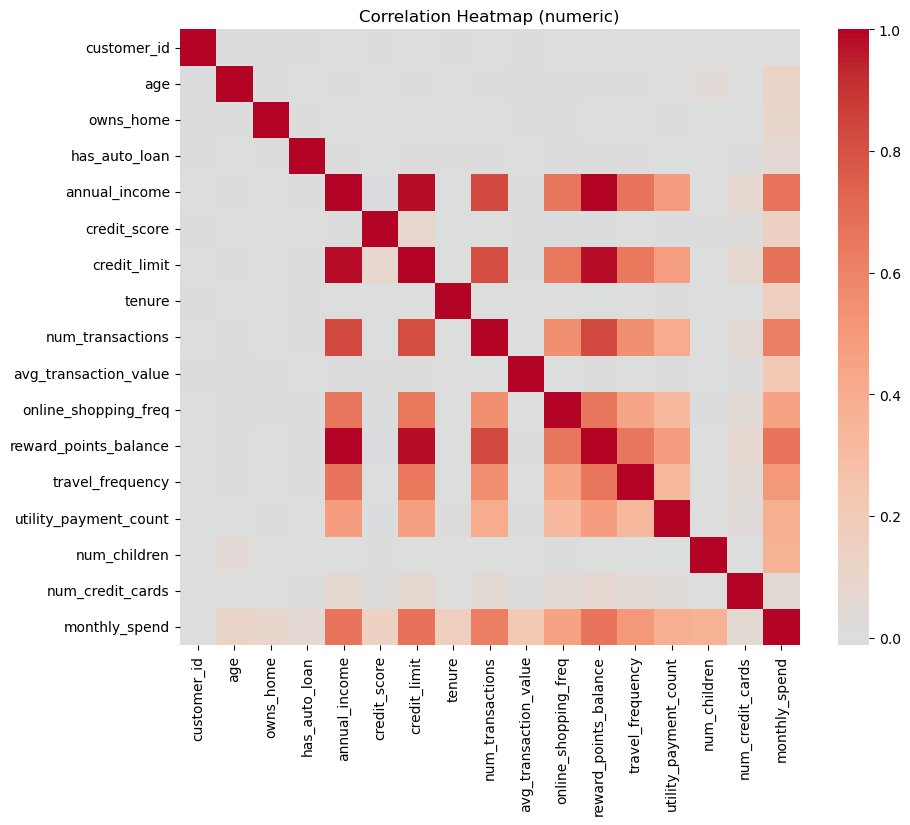

In [5]:
# =========================================
# 3. Exploratory visualizations
# =========================================

target = "monthly_spend"
id_col = "customer_id"

# Target distribution
plt.figure()
sns.histplot(analysis[target], bins=40, kde=True)
plt.title("Distribution of Monthly Spend")
plt.xlabel("monthly_spend")
plt.ylabel("Count")
plt.show()

# Example: numeric features histograms
numeric_cols_raw = [
    "age", "annual_income", "credit_score",
    "num_credit_cards", "credit_limit",
    "num_transactions", "avg_transaction_value",
    "online_shopping_freq", "reward_points_balance"
]

for col in numeric_cols_raw:
    if col in analysis.columns:
        plt.figure()
        sns.histplot(analysis[col], bins=40, kde=False)
        plt.title(f"Distribution of {col}")
        plt.show()

# Example: boxplot of spend by card_type
if "card_type" in analysis.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=analysis, x="card_type", y=target)
    plt.title("Monthly Spend by Card Type")
    plt.show()

# Optional: correlation heatmap for numeric variables
num_for_corr = analysis.select_dtypes(include=["int64", "float64"])
corr = num_for_corr.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (numeric)")
plt.show()

In [6]:
# =========================================
# 4. Dummy creation example (for EDA, not model)
# =========================================

cat_cols_raw = [
    "gender", "marital_status", "education_level",
    "region", "employment_status", "card_type"
]

cat_cols_raw = [c for c in cat_cols_raw if c in analysis.columns]

analysis_dummies_example = pd.get_dummies(
    analysis[cat_cols_raw],
    drop_first=True
)

print("Dummy example shape:", analysis_dummies_example.shape)
display(analysis_dummies_example.head())


Dummy example shape: (40000, 12)


,gender_male,marital_status_single,education_level_graduate,education_level_high school,region_northeast,region_south,region_west,employment_status_self-employed,employment_status_student,employment_status_unemployed,card_type_platinum,card_type_standard
0,False,False,False,True,True,False,False,False,False,True,False,True
1,True,False,False,True,False,True,False,False,False,True,False,False
2,False,False,False,False,False,False,True,False,False,True,False,True
3,False,False,False,True,True,False,False,False,False,True,False,True
4,False,True,False,False,False,False,True,True,False,False,False,True


In [7]:
# =========================================
# 5. Economics-of-spending feature engineering
# =========================================

def add_econ_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    eps = 1.0
    
    # Basic columns exist check
    has = lambda col: col in df.columns
    
    # 1. Capacity features
    if has("credit_limit") and has("num_credit_cards"):
        df["limit_per_card"] = df["credit_limit"] / (df["num_credit_cards"] + 1)
    if has("annual_income") and has("num_credit_cards"):
        df["income_per_card"] = df["annual_income"] / (df["num_credit_cards"] + 1)
    
    # 2. Utilization-related
    if has("credit_limit") and has("annual_income"):
        df["limit_to_income"] = df["credit_limit"] / (df["annual_income"] + eps)
    if has("num_transactions") and has("num_credit_cards"):
        df["txn_per_card"] = df["num_transactions"] / (df["num_credit_cards"] + 1)
    
    # 3. Transaction-volume proxy
    if has("num_transactions") and has("avg_transaction_value"):
        df["txn_amount_proxy"] = df["num_transactions"] * df["avg_transaction_value"]
    
    # 4. Shares
    if has("online_shopping_freq") and has("num_transactions"):
        df["online_share"] = df["online_shopping_freq"] / (df["num_transactions"] + 1)
    if has("utility_payment_count") and has("num_transactions"):
        df["utilities_share"] = df["utility_payment_count"] / (df["num_transactions"] + 1)
    
    # 5. Intensities (per year of tenure)
    if has("online_shopping_freq") and has("tenure"):
        df["online_txn_intensity"] = df["online_shopping_freq"] / (df["tenure"] + 1)
    if has("travel_frequency") and has("tenure"):
        df["travel_intensity"] = df["travel_frequency"] / (df["tenure"] + 1)
    if has("utility_payment_count") and has("tenure"):
        df["utilities_intensity"] = df["utility_payment_count"] / (df["tenure"] + 1)
    
    # 6. Rewards efficiency
    if has("reward_points_balance") and has("num_transactions"):
        df["rewards_per_txn"] = df["reward_points_balance"] / (df["num_transactions"] + 1)
    
    return df

analysis_fe = add_econ_features(analysis)
scoring_fe  = add_econ_features(scoring)

print("Analysis with econ features:", analysis_fe.shape)
print("Scoring with econ features:", scoring_fe.shape)

Analysis with econ features: (40000, 34)
Scoring with econ features: (10000, 33)


In [8]:
# =========================================
# 6. Log-transform skewed positive features
# =========================================

log_features = [
    "annual_income",
    "credit_limit",
    "num_transactions",
    "avg_transaction_value",
    "online_shopping_freq",
    "reward_points_balance",
    "travel_frequency",
    "utility_payment_count",
    "txn_amount_proxy",
    "limit_per_card",
    "income_per_card",
    "txn_per_card",
    "rewards_per_txn"
]

analysis_fe = analysis_fe.copy()
scoring_fe  = scoring_fe.copy()

for col in log_features:
    if col in analysis_fe.columns:
        analysis_fe[col] = np.log1p(analysis_fe[col])
    if col in scoring_fe.columns:
        scoring_fe[col]  = np.log1p(scoring_fe[col])

In [9]:
# =========================================
# 7. Define X, y and train/validation split
# =========================================

target = "monthly_spend"
id_col = "customer_id"

y = analysis_fe[target]
X = analysis_fe.drop(columns=[target, id_col])   # <-- do NOT include ID as feature

X_test_full = scoring_fe.copy()
X_test = X_test_full.drop(columns=[id_col])

numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "bool", "category"]).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(cat_cols))

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, "Valid shape:", X_valid.shape)

Numeric features: 26
Categorical features: 6
Train shape: (30000, 32) Valid shape: (10000, 32)


In [10]:
# =========================================
# 8. Preprocessing (imputation + scaling + one-hot)
# =========================================

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

In [12]:
# =========================================
# 9. Gradient Boosting with CV
# =========================================

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

gb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__min_samples_leaf": [5, 10, 20],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__max_features": [None, "sqrt"],
    "model__loss": ["ls", "huber"]
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_search = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
print("Best GB CV RMSE:", -gb_search.best_score_)
print("Best GB params:", gb_search.best_params_)

# Validation performance
y_valid_pred = best_gb.predict(X_valid)
valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
print("Validation RMSE:", valid_rmse)

Fitting 5 folds for each of 432 candidates, totalling 2160 fits


/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:516: FitFailedWarning: 
1080 fits failed out of a total of 2160.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
172 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/opt/anaconda3/envs/pred_env/lib/python3.13/site-packages/skl

Best GB CV RMSE: 253.78304037900307
Best GB params: {'model__learning_rate': 0.05, 'model__loss': 'huber', 'model__max_depth': 4, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 400, 'model__subsample': 0.7}
Validation RMSE: 255.28240291160344


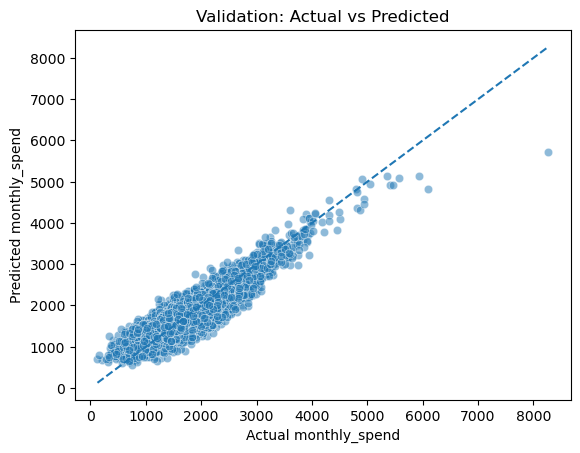

In [13]:
plt.figure()
sns.scatterplot(x=y_valid, y=y_valid_pred, alpha=0.5)
plt.xlabel("Actual monthly_spend")
plt.ylabel("Predicted monthly_spend")
plt.title("Validation: Actual vs Predicted")
plt.plot([y_valid.min(), y_valid.max()],
         [y_valid.min(), y_valid.max()],
         ls="--")
plt.show()

In [16]:
# =========================================
# 9. Gradient Boosting with CV
# =========================================

rmse_scorer = make_scorer(
    lambda yt, yp: np.sqrt(mean_squared_error(yt, yp)),
    greater_is_better=False
)

gb_model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
])

gb_param_grid = {
    "model__n_estimators": [200, 300, 400],
    "model__learning_rate": [0.05, 0.1],
    "model__max_depth": [3, 4],
    "model__min_samples_leaf": [5, 10, 20],
    "model__subsample": [0.7, 0.9, 1.0],
    "model__max_features": [None, "sqrt"],
    "model__loss": ["squared_error", "huber"]   # <- use this, NOT "ls"
}

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gb_search = GridSearchCV(
    estimator=gb_model,
    param_grid=gb_param_grid,
    scoring=rmse_scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
print("Best GB CV RMSE:", -gb_search.best_score_)
print("Best GB params:", gb_search.best_params_)

# Validation performance
y_valid_pred = best_gb.predict(X_valid)
valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_pred))
print("Validation RMSE:", valid_rmse)

UsageError: Line magic function `%%time` not found.


In [17]:
# Start from your existing preprocess, X_train, y_train, etc.

gb_refine = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(random_state=1031))
])

gb_refine_grid = {
    "model__n_estimators": [350, 400, 450, 550],
    "model__learning_rate": [0.03, 0.04, 0.05, 0.06],
    "model__max_depth": [3, 4],
    "model__min_samples_leaf": [3, 5, 8],
    "model__subsample": [0.6, 0.7, 0.8],
    "model__max_features": ["sqrt"],
    "model__loss": ["huber"]   # locked since it worked well
}

cv = KFold(n_splits=5, shuffle=True, random_state=1031)

gb_refine_search = GridSearchCV(
    estimator=gb_refine,
    param_grid=gb_refine_grid,
    scoring=rmse_scorer,   # same as before
    cv=cv,
    n_jobs=-1,
    verbose=1
)

gb_refine_search.fit(X_train, y_train)

best_gb_ref = gb_refine_search.best_estimator_
print("Refined GB CV RMSE:", -gb_refine_search.best_score_)
print("Refined GB params:", gb_refine_search.best_params_)

y_valid_ref = best_gb_ref.predict(X_valid)
ref_valid_rmse = np.sqrt(mean_squared_error(y_valid, y_valid_ref))
print("Refined validation RMSE:", ref_valid_rmse)

Fitting 5 folds for each of 288 candidates, totalling 1440 fits
Refined GB CV RMSE: 253.55094015158647
Refined GB params: {'model__learning_rate': 0.05, 'model__loss': 'huber', 'model__max_depth': 3, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 550, 'model__subsample': 0.8}
Refined validation RMSE: 254.88663787786936


In [19]:
# 1. Big model with many trees, same best params except n_estimators
gb_big = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", GradientBoostingRegressor(
        random_state=1031,
        loss="huber",
        learning_rate=0.05,
        max_depth=4,
        min_samples_leaf=5,
        subsample=0.7,
        max_features="sqrt",
        n_estimators=1200
    ))
])

gb_big.fit(X_train, y_train)

# 2. Staged predictions to find best number of trees
model_inner = gb_big.named_steps["model"]

valid_rmse_list = []
for i, y_pred_stage in enumerate(model_inner.staged_predict(
        gb_big.named_steps["preprocess"].transform(X_valid)), start=1):
    rmse_i = np.sqrt(mean_squared_error(y_valid, y_pred_stage))
    valid_rmse_list.append(rmse_i)

best_n = np.argmin(valid_rmse_list) + 1
best_rmse_stage = valid_rmse_list[best_n - 1]
print("Best staged n_estimators:", best_n)
print("Best staged validation RMSE:", best_rmse_stage)

Best staged n_estimators: 713
Best staged validation RMSE: 254.95836398895872
